In [1]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input/luyucwnu/tlmuav-anomaly-detection-datasets/IMU/ALL_FAIL_LOG_IMU_0_Random.csv"):
  

In [3]:
import pandas as pd

data = pd.read_csv(
    '/kaggle/input/datasets/luyucwnu/tlmuav-anomaly-detection-datasets/dataset/IMU/ALL_FAIL_LOG_IMU_0_Random.csv')

print(data.shape)
print(data.columns.tolist())
data.head()


(21597, 17)
['LineNo', 'abTimeUS', 'abI', 'abGyrX', 'abGyrY', 'abGyrZ', 'abAccX', 'abAccY', 'abAccZ', 'abEG', 'abEA', 'abT', 'abGH', 'abAH', 'abGHz', 'abAHz', 'labels']


,LineNo,abTimeUS,abI,abGyrX,abGyrY,abGyrZ,abAccX,abAccY,abAccZ,abEG,abEA,abT,abGH,abAH,abGHz,abAHz,labels
0,14707,47623443,0,0.000652,0.000699,0.000664,-0.001625,-0.000529,-9.817689,0,0,27.83643,1,1,1000,1000,0
1,294758,359383689,0,3.323413,-5.883018,-6.913023,0.528758,-1.198488,-6.869982,0,0,38.92860,1,1,999,999,3
2,288150,352023301,0,4.783490,-6.518798,-28.446280,-0.080333,-0.054142,-8.466424,0,0,38.77781,1,1,999,999,3
3,265078,326383561,0,1.152616,-2.402375,-0.117582,-0.328573,0.036870,-10.058320,0,0,38.22263,1,1,999,999,0
4,105572,148903748,0,1.405822,-2.136524,0.033208,-5.092781,-0.064265,-8.411710,0,0,32.75413,1,1,1000,1000,1


# Preprocessing and Exploring data



In [4]:
print("Dataset Shape:", data.shape)
print("\nColumns:\n", data.columns)
print("\nSample Data:\n", data.head())
print("\nMissing Values:\n", data.isnull().sum())

Dataset Shape: (21597, 17)

Columns:
 Index(['LineNo', 'abTimeUS', 'abI', 'abGyrX', 'abGyrY', 'abGyrZ', 'abAccX',
       'abAccY', 'abAccZ', 'abEG', 'abEA', 'abT', 'abGH', 'abAH', 'abGHz',
       'abAHz', 'labels'],
      dtype='object')

Sample Data:
    LineNo   abTimeUS  abI    abGyrX    abGyrY     abGyrZ    abAccX    abAccY  \
0   14707   47623443    0  0.000652  0.000699   0.000664 -0.001625 -0.000529   
1  294758  359383689    0  3.323413 -5.883018  -6.913023  0.528758 -1.198488   
2  288150  352023301    0  4.783490 -6.518798 -28.446280 -0.080333 -0.054142   
3  265078  326383561    0  1.152616 -2.402375  -0.117582 -0.328573  0.036870   
4  105572  148903748    0  1.405822 -2.136524   0.033208 -5.092781 -0.064265   

      abAccZ  abEG  abEA       abT  abGH  abAH  abGHz  abAHz  labels  
0  -9.817689     0     0  27.83643     1     1   1000   1000       0  
1  -6.869982     0     0  38.92860     1     1    999    999       3  
2  -8.466424     0     0  38.77781     1     1    999

In [ ]:
print("\nData Types:\n", data.dtypes)

In [5]:

if 'labels' in data.columns:
    label_counts = data['labels'].value_counts()
    # Define specific colors for 5 labels
    colors = ["#FF91A4", "#f6c344", "#79d970", "#F4E1C1", "#6495ED"]

    # Plot the donut chart
    plt.figure(figsize=(4, 5))
    plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', sta|rtangle=90, colors=colors, wedgeprops={'width': 0.4})
    plt.axis('equal')
    plt.show()



SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (2447971116.py, line 8)

In [6]:
# Encoding Categorical Data
if 'labels' in data.columns:
    label_encoder = LabelEncoder()
    data['labels'] = label_encoder.fit_transform(data['labels'])
    print("\nLabel Encoding Complete. Classes:", label_encoder.classes_)


Label Encoding Complete. Classes: [0 1 2 3 4]


In [7]:
# Feature Selection
X = data.drop(columns=['labels']).values  # Features
y = data['labels'].values  # Target

In [8]:
X.shape

(21597, 16)

In [9]:
# Scaling Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# One-hot encode the labels
y_encoded = to_categorical(y, num_classes=len(np.unique(y)))

In [11]:
window_size = 5

X_windows = []
y_windows = []

for i in range(len(X_scaled) - window_size + 1):
    X_windows.append(X_scaled[i:i+window_size])
    y_windows.append(y_encoded[i+window_size-1])   # <-- Correct

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

print(X_windows.shape)
print(y_windows.shape)

input_shape = X_windows.shape[1:]
num_classes = y_windows.shape[1]

(21593, 5, 16)
(21593, 5)


In [12]:
for label in data['labels'].unique():
    print(f"\nValues for label: {label}")
    print(data[data['labels'] == label].head())


Values for label: 0
   LineNo   abTimeUS  abI    abGyrX    abGyrY    abGyrZ    abAccX    abAccY  \
0   14707   47623443    0  0.000652  0.000699  0.000664 -0.001625 -0.000529   
3  265078  326383561    0  1.152616 -2.402375 -0.117582 -0.328573  0.036870   
5  337042  406384048    0  2.900586 -0.807860  0.105744 -4.811216  0.004499   
7    8795   24183656    0  0.000277  0.000300  0.000334 -0.001067 -0.001277   
8  147682  195903274    0 -2.509628 -0.916222  0.052631 -4.793435 -0.102203   

      abAccZ  abEG  abEA       abT  abGH  abAH  abGHz  abAHz  labels  
0  -9.817689     0     0  27.83643     1     1   1000   1000       0  
3 -10.058320     0     0  38.22263     1     1    999    999       0  
5  -8.781097     0     0  39.80902     1     1   1000   1000       0  
7  -9.816331     0     0  26.44160     1     1    999    999       0  
8  -8.323733     0     0  34.52991     1     1   1000   1000       0  

Values for label: 3
    LineNo   abTimeUS  abI    abGyrX    abGyrY     abGyrZ

# Model

In [13]:
# Define the TCN Block
def TCN_Block(filters, kernel_size, dilation_rate):
    return tf.keras.Sequential([
        Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', dilation_rate=dilation_rate),
        BatchNormalization(),
        Activation('relu')
    ])
    

In [14]:
# Define the Attention Layer
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1],), initializer="glorot_uniform", trainable=True)

    def call(self, inputs):
        u_t = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a_t = tf.nn.softmax(tf.tensordot(u_t, self.u, axes=1), axis=1)
        output = tf.reduce_sum(inputs * tf.expand_dims(a_t, -1), axis=1)
        return output

In [15]:
# Define the TCN with Attention Model
def build_tcn_attention_model(input_shape, num_classes):
    # inputs = Input(shape=input_shape)
# def build_tcn_attention_model(X_windows, num_classes):
    inputs = Input(shape=input_shape)
     # Replacing input_shape with X_windows.shape
    # TCN Layers
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=4)(inputs)
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=8)(x)
    x = TCN_Block(filters=64, kernel_size=3, dilation_rate=16)(x)

    # Attention mechanism
    attention_output = AttentionLayer()(x)

    # Classification
    classification = Dense(num_classes, activation='softmax')(attention_output)

    # Define and compile the model
    model = Model(inputs=inputs, outputs=classification)
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=categorical_crossentropy,
                  metrics=['accuracy'])

    return model


In [ ]:
# input_shape
X_windows.shape[2]

In [ ]:
X_windows.shape[1]

In [ ]:
X_windows.shape[0]

In [27]:
X_windows.shape

(21593, 5, 16)

In [16]:
# Input shape for TCN
input_shape = (X_windows.shape[1], X_windows.shape[2])
num_classes = y_windows.shape[1]

In [17]:
# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
accuraciesKF = []
label_accuraciesKF = []

for train_index, val_index in kf.split(X_windows):
    print(f"\nTraining fold {fold_no}...")

    # Split data
    X_train_foldKF, X_val_foldKF = X_windows[train_index], X_windows[val_index]
    y_train_foldKF, y_val_foldKF = y_windows[train_index], y_windows[val_index]

    # Build and train the model
    # modelKF = build_tcn_attention_model(input_shape, num_classes)
    modelKF = build_tcn_attention_model(input_shape, num_classes)
    modelKF.fit(X_train_foldKF, y_train_foldKF, epochs=50, batch_size=32, verbose=0, validation_data=(X_val_foldKF, y_val_foldKF))
   

    # Evaluate the model
    lossKF, accuracyKF = modelKF.evaluate(X_val_foldKF, y_val_foldKF, verbose=0)
    print(f"Validation Accuracy for fold {fold_no}: {accuracyKF:.4f}")
    accuraciesKF.append(accuracyKF)

    # Predictions
    y_predKF = modelKF.predict(X_val_foldKF)
    y_pred_classesKF = np.argmax(y_predKF, axis=1)
    y_true_classesKF = np.argmax(y_val_foldKF, axis=1)

    # Accuracy per label
    label_accKF = []
    for label in range(num_classes):
        label_indicesKF = (y_true_classesKF == label)
        label_accKF.append(accuracy_score(y_true_classesKF[label_indicesKF], y_pred_classesKF[label_indicesKF]))
    label_accuraciesKF.append(label_accKF)

    fold_no += 1




Training fold 1...


2026-07-06 05:37:04.159809: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Validation Accuracy for fold 1: 0.9664
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training fold 2...
Validation Accuracy for fold 2: 0.9764
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training fold 3...
Validation Accuracy for fold 3: 0.9755
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training fold 4...
Validation Accuracy for fold 4: 0.9759
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training fold 5...
Validation Accuracy for fold 5: 0.9713
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [18]:
modelKF.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 5, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_12 (Sequential)      │ (None, 5, 64)          │         3,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 5, 64)          │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_14 (Sequential)      │ (None, 5, 64)          │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_4               │ (None, 64)             │         4,224 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,705 (385.57 KB)

 Trainable params: 32,773 (128.02 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 65,548 (256.05 KB)

In [19]:
# Calculate average accuracy
average_accuracyKF = np.mean(accuraciesKF)
print(f"\nAverage Accuracy across all folds: {average_accuracyKF:.4f}")


Average Accuracy across all folds: 0.9731


In [20]:
# Average accuracy per label
label_accuraciesKF = np.mean(label_accuraciesKF, axis=0)
for idx, acc in enumerate(label_accuraciesKF):
    print(f"Label {idx} Accuracy: {acc:.4f}")

Label 0 Accuracy: 0.9675
Label 1 Accuracy: 0.9790
Label 2 Accuracy: 0.9779
Label 3 Accuracy: 0.9614
Label 4 Accuracy: 0.9871


In [21]:
# Evaluate the last fold predictions
y_predKF = modelKF.predict(X_val_foldKF)
y_pred_classesKF = np.argmax(y_predKF, axis=1)
y_true_classesKF = np.argmax(y_val_foldKF, axis=1)

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [22]:
import pandas as pd
import numpy as np
feature_names = ["LineNo", "abTimeUS", "abI", "abGyrX", "abGyrY", "abGyrZ", "abAccX",
       "abAccY", "abAccZ", "abEG", "abEA", "abT", "abGH", "abAH", "abGHz",
       "abAHz"]


# Step 1: Get Model Predictions
y_pred_probs = modelKF.predict(X_windows, verbose=0)

# Convert probabilities to labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_windows, axis=1)

# Find misclassified windows
mismatch_indices = np.where(y_true_labels != y_pred_labels)[0]

print("Total Misclassified Windows:", len(mismatch_indices))

# Extract the last time step from each misclassified window
X_last = X_windows[mismatch_indices, -1, :]

# Create DataFrame
df_mismatches = pd.DataFrame(
    X_last,
    columns=feature_names
)

# Add labels
df_mismatches["Actual_Label"] = y_true_labels[mismatch_indices]
df_mismatches["Predicted_Label"] = y_pred_labels[mismatch_indices]

# Add original window index
df_mismatches.insert(0, "Window_Index", mismatch_indices)

print(df_mismatches)

# Optional: Save to CSV
df_mismatches.to_csv("Misclassified_Windows.csv", index=False)




Total Misclassified Windows: 465
     Window_Index    LineNo  abTimeUS  abI    abGyrX    abGyrY    abGyrZ  \
0              16  1.490079  1.407008  0.0 -0.585241 -1.205299  0.083198   
1             117 -1.100177 -1.199770  0.0  0.948428  0.890779  0.080266   
2             183 -1.101025 -1.200690  0.0  1.130781 -0.564771  0.086413   
3             223 -1.128433 -1.227999  0.0 -0.959508  1.005192  0.115190   
4             257 -1.153065 -1.252855  0.0  1.221977  0.573514  0.088499   
..            ...       ...       ...  ...       ...       ...       ...   
460         21495  0.157247  0.294461  0.0 -0.857192  0.809175 -0.040112   
461         21551  0.728921  0.869143  0.0  1.503652  0.362142  0.094139   
462         21562 -1.109392 -0.981622  0.0 -0.522028  1.276152  0.086866   
463         21573  0.154184  0.291394  0.0 -0.700948  1.099680  0.154768   
464         21581  0.341393  0.479479  0.0  1.224450 -0.296946  0.087453   

       abAccX    abAccY    abAccZ  abEG  abEA       ab

In [23]:
import pandas as pd
import numpy as np

feature_names = ["LineNo", "abTimeUS", "abI", "abGyrX", "abGyrY", "abGyrZ", "abAccX",
       "abAccY", "abAccZ", "abEG", "abEA", "abT", "abGH", "abAH", "abGHz",
       "abAHz"]

# Predict on windowed data
y_pred_probs = modelKF.predict(X_windows, verbose=0)

# Convert probabilities to labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_windows, axis=1)

# Find misclassified windows
mismatch_indices = np.where(y_true_labels != y_pred_labels)[0]

# Extract the last time step of each misclassified window
X_last = X_windows[mismatch_indices, -1, :]

# Create dataframe
df_mismatches = pd.DataFrame(
    X_last,
    columns=feature_names
)

# Add metadata
df_mismatches.insert(0, "Window_Index", mismatch_indices)
df_mismatches["Actual_Label"] = y_true_labels[mismatch_indices]
df_mismatches["Predicted_Label"] = y_pred_labels[mismatch_indices]

print(df_mismatches)


     Window_Index    LineNo  abTimeUS  abI    abGyrX    abGyrY    abGyrZ  \
0              16  1.490079  1.407008  0.0 -0.585241 -1.205299  0.083198   
1             117 -1.100177 -1.199770  0.0  0.948428  0.890779  0.080266   
2             183 -1.101025 -1.200690  0.0  1.130781 -0.564771  0.086413   
3             223 -1.128433 -1.227999  0.0 -0.959508  1.005192  0.115190   
4             257 -1.153065 -1.252855  0.0  1.221977  0.573514  0.088499   
..            ...       ...       ...  ...       ...       ...       ...   
460         21495  0.157247  0.294461  0.0 -0.857192  0.809175 -0.040112   
461         21551  0.728921  0.869143  0.0  1.503652  0.362142  0.094139   
462         21562 -1.109392 -0.981622  0.0 -0.522028  1.276152  0.086866   
463         21573  0.154184  0.291394  0.0 -0.700948  1.099680  0.154768   
464         21581  0.341393  0.479479  0.0  1.224450 -0.296946  0.087453   

       abAccX    abAccY    abAccZ  abEG  abEA       abT  abGH  abAH     abGHz  \
0    0

In [24]:
# Step 1: Identify correctly classified windows
correct_indices = np.where(y_true_labels == y_pred_labels)[0]

# Step 2: Extract the last time step of each correctly classified window
X_last = X_windows[correct_indices, -1, :]

# Step 3: Create DataFrame
df_correct = pd.DataFrame(
    X_last,
    columns=feature_names
)

# Add metadata
df_correct.insert(0, "Window_Index", correct_indices)
df_correct["Actual_Label"] = y_true_labels[correct_indices]
df_correct["Predicted_Label"] = y_pred_labels[correct_indices]

# Step 4: Save to CSV
df_correct.to_csv("correctly_classified.csv", index=False)

# Display
print(df_correct.head())

   Window_Index    LineNo  abTimeUS  abI    abGyrX    abGyrY    abGyrZ  \
0             0 -0.781795 -0.876992  0.0  0.771237 -1.126770  0.081487   
1             1  1.182278  1.098038  0.0  1.620857 -0.399743  0.113888   
2             2 -1.015130 -1.114168  0.0 -0.939684  1.076612  0.215068   
3             3 -1.602968 -1.833671  0.0 -0.027671  0.042472  0.066802   
4             4 -0.424482 -0.516477  0.0 -1.454294 -0.459037  0.090163   

     abAccX    abAccY    abAccZ  abEG  abEA       abT  abGH  abAH     abGHz  \
0 -1.825136 -0.134387 -0.182883   0.0   0.0 -0.783275   0.0   0.0  0.848641   
1 -1.697792 -0.059116 -0.268722   0.0   0.0  1.016416   0.0   0.0  0.848641   
2  0.215711 -0.063800 -0.602293   0.0   0.0 -1.122423   0.0   0.0  0.848641   
3  0.477704 -0.065439 -0.509293   0.0   0.0 -2.393591   0.0   0.0 -1.178355   
4 -1.689750 -0.175914 -0.162438   0.0   0.0 -0.330276   0.0   0.0  0.848641   

      abAHz  Actual_Label  Predicted_Label  
0  0.848641             1          

In [25]:
df_mismatches.to_csv("misclassified_samples.csv", index=False)
print("CSV file 'misclassified_samples.csv' saved successfully!")


CSV file 'misclassified_samples.csv' saved successfully!


In [26]:
# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true_classesKF, y_pred_classesKF,digits = 4))


Classification Report:

              precision    recall  f1-score   support

           0     0.9738    0.9641    0.9690      2007
           1     0.9353    0.9902    0.9620       613
           2     0.9659    0.9597    0.9628       620
           3     0.9866    0.9787    0.9826       375
           4     0.9942    0.9815    0.9878       703

    accuracy                         0.9713      4318
   macro avg     0.9712    0.9748    0.9728      4318
weighted avg     0.9716    0.9713    0.9713      4318



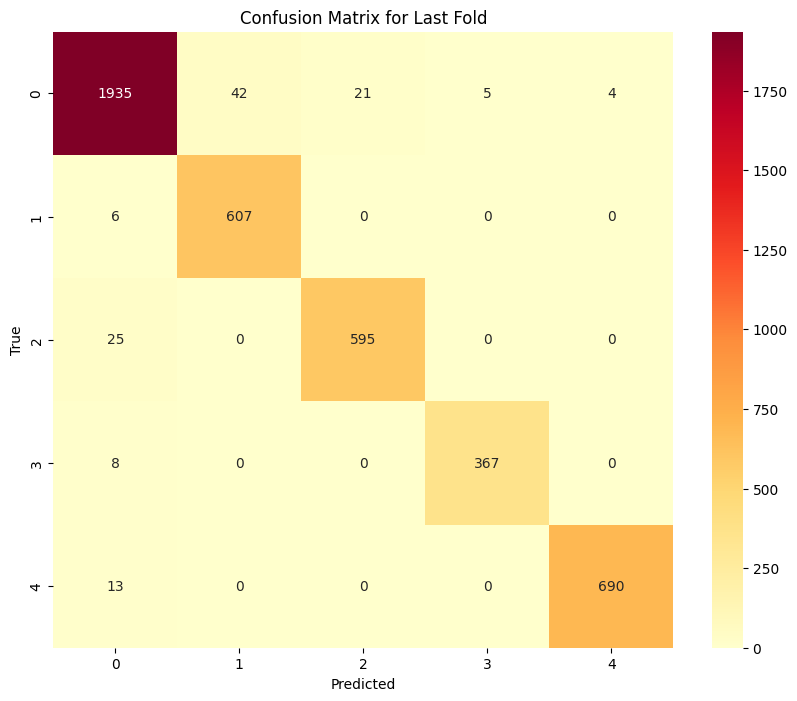

In [28]:
# Confusion Matrix
conf_matrixKF = tf.math.confusion_matrix(y_true_classesKF, y_pred_classesKF)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrixKF, annot=True, fmt='d', cmap='YlOrRd')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.title('Confusion Matrix for Last Fold')
plt.show()

In [ ]:
if 'labels' in data.columns:
    label_countsKF = data['labels'].value_counts()
    print("\nLabel Distribution:\n", label_countsKF)
    plt.figure(figsize=(5, 5))
    plt.pie(label_countsKF, labels=label_countsKF.index, autopct='%1.1f%%', startangle=90)
    plt.title('Original Distribution of Labels')
    plt.show()

0    1987
4     694
1     649
2     616
3     372
Name: count, dtype: int64


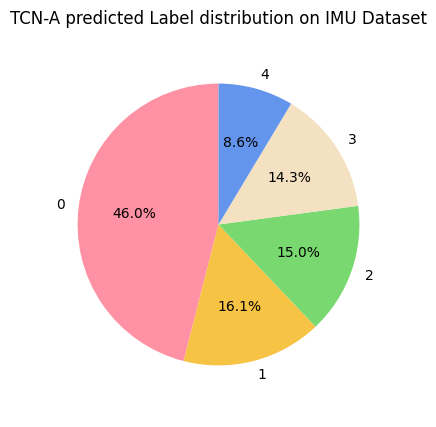

In [29]:

# Get the label distribution after training
# Get the predicted labels after training
class_counts = pd.Series(y_pred_classesKF).value_counts()
print(class_counts)
# Plot pie chart of predicted labels
plt.figure(figsize=(4, 5))
colors = ["#FF91A4", "#f6c344", "#79d970", "#F4E1C1", "#6495ED"]
plt.pie(pd.Series(y_pred_classesKF).value_counts(), labels=label_encoder.classes_, autopct='%1.1f%%', startangle=90,colors=colors)
plt.axis('equal')
plt.title('TCN-A predicted Label distribution on IMU Dataset')
plt.show()